In [6]:
pip install opencv-python

   ---------------------------------------- 0.0/40.2 MB ? eta -:--:--
   - -------------------------------------- 1.0/40.2 MB 10.3 MB/s eta 0:00:04
   --- ------------------------------------ 3.4/40.2 MB 10.7 MB/s eta 0:00:04
   ----- ---------------------------------- 5.8/40.2 MB 11.1 MB/s eta 0:00:04
   -------- ------------------------------- 8.7/40.2 MB 12.2 MB/s eta 0:00:03
   ----------- ---------------------------- 11.3/40.2 MB 12.2 MB/s eta 0:00:03
   ------------ --------------------------- 12.8/40.2 MB 11.7 MB/s eta 0:00:03
   --------------- ------------------------ 15.7/40.2 MB 11.7 MB/s eta 0:00:03
   ------------------ --------------------- 18.6/40.2 MB 11.9 MB/s eta 0:00:02
   ---------------------- ----------------- 22.3/40.2 MB 12.5 MB/s eta 0:00:02
   -------------------------- ------------- 27.0/40.2 MB 13.6 MB/s eta 0:00:01
   ------------------------------ --------- 30.7/40.2 MB 14.0 MB/s eta 0:00:01
   ---------------------------------- ----- 35.1/40.2 MB 14.7 MB/

In [1]:
import tensorflow as tf
import matplotlib.pyplot as plt
import cv2
import os
import numpy as np
from tensorflow.keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import RMSprop
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D
import warnings
warnings.filterwarnings("ignore")

In [2]:
os.chdir(r"C:\Users\dhami\data cnn")

In [3]:
os.getcwd

<function nt.getcwd()>

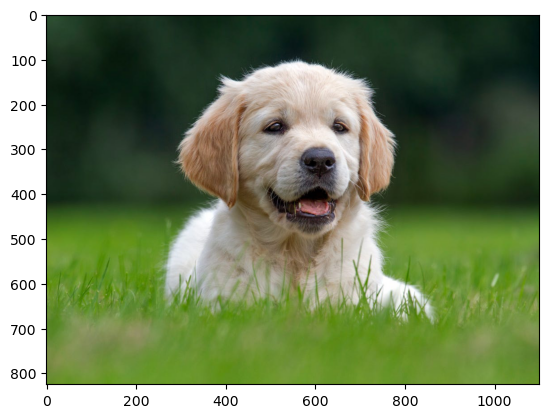

In [4]:
img=image.load_img(r"C:\Users\dhami\data cnn\training\dog\1.jpg")
plt.imshow(img)

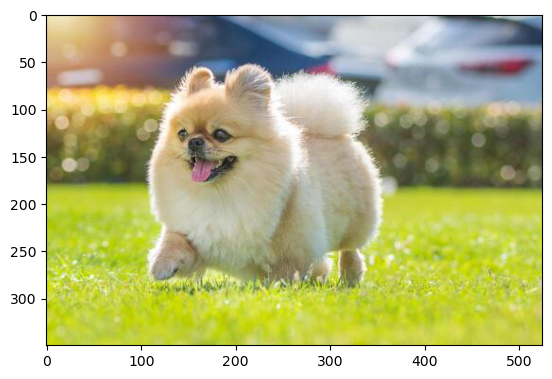

In [5]:
img = image.load_img(r"C:\Users\dhami\data cnn\testing\2.jpg")
plt.imshow(img)

In [6]:
train = ImageDataGenerator(rescale= 1/255)
validation = ImageDataGenerator(rescale= 1/255)

In [7]:
tr_location = r"C:\Users\dhami\data cnn\training"
val_location = r"C:\Users\dhami\data cnn\validation"

In [8]:
train_data=train.flow_from_directory(tr_location, target_size=(200,200), batch_size=3, class_mode='binary')
valid_data = validation.flow_from_directory(val_location, target_size=(200,200), batch_size=3, class_mode='binary')

Found 8 images belonging to 2 classes.
Found 4 images belonging to 2 classes.


In [9]:
train_data.class_indices

{'cat': 0, 'dog': 1}

In [10]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Conv2D(16,(3,3),activation="relu",input_shape=(200,200,3)),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(32,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Conv2D(64,(3,3),activation="relu"),
    tf.keras.layers.MaxPool2D(2,2),
    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(512,activation="relu"),
    tf.keras.layers.Dense(1,activation="sigmoid")])

In [11]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 198, 198, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 99, 99, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 97, 97, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 48, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 46, 46, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 23, 23, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 33856)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    17,334,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           513 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 17,358,881 (66.22 MB)

 Trainable params: 17,358,881 (66.22 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(loss='binary_crossentropy',optimizer=RMSprop(learning_rate=0.001),metrics=["accuracy"])

In [13]:
model.fit(train_data,steps_per_epoch=3, epochs= 10 , validation_data=valid_data)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 834ms/step - accuracy: 0.3750 - loss: 3.6399 - val_accuracy: 0.5000 - val_loss: 0.8113
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 289ms/step - accuracy: 0.7500 - loss: 0.7669 - val_accuracy: 0.5000 - val_loss: 0.6838
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 309ms/step - accuracy: 0.3750 - loss: 0.7573 - val_accuracy: 1.0000 - val_loss: 0.5578
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 293ms/step - accuracy: 0.6250 - loss: 1.0328 - val_accuracy: 0.5000 - val_loss: 0.6019
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 286ms/step - accuracy: 0.6250 - loss: 0.6590 - val_accuracy: 1.0000 - val_loss: 0.4883
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.6250 - loss: 0.5795 - val_accuracy: 1.0000 - val_loss: 0.3979
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 278ms/step - accuracy: 0.8750 - loss: 0.4962 - val_accuracy: 0.5000 - val_loss: 0.5751
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 291ms/step - accuracy: 0.6250 - loss: 1.1560 - val_accuracy: 1.0000 - val_loss:

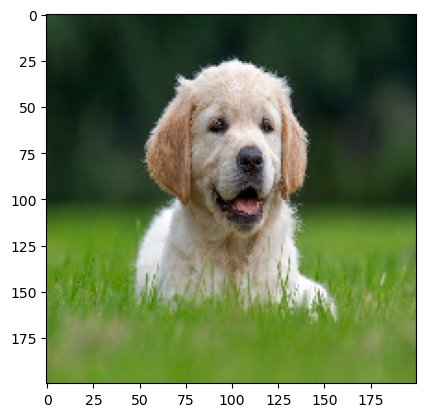

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 186ms/step
Dog


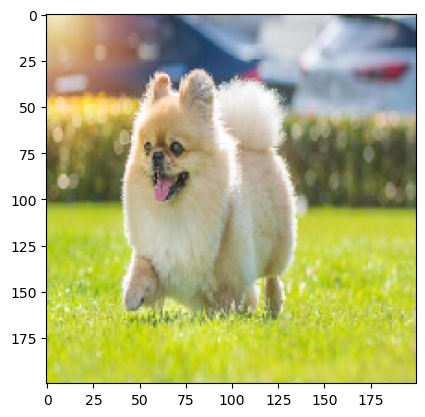

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
Dog


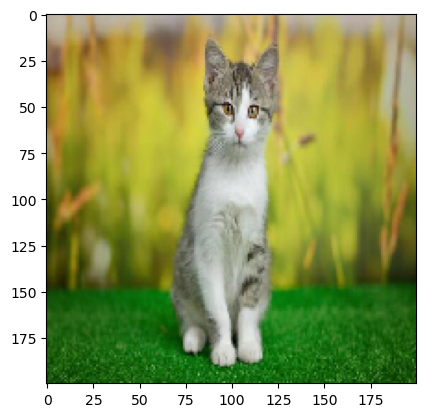

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
Cat


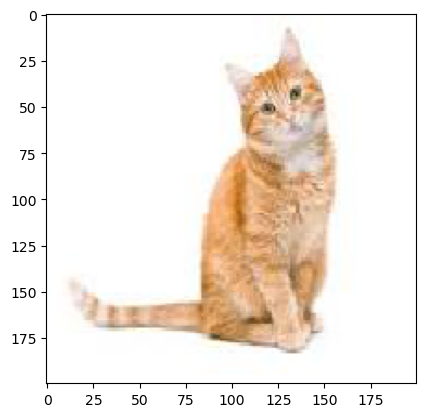

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
Cat


In [14]:
path = r"C:\Users\dhami\data cnn\testing"
for i in os.listdir(path):
    img = image.load_img(path+"/"+i,target_size=(200,200))
    plt.imshow(img)
    plt.show()
    
    x = image.img_to_array(img)
    x = np.expand_dims(x,axis = 0)
    pic = np.vstack([x])
    val = model.predict(pic)
    if val==0:
        print("Cat")
    else:
        print("Dog")